# Monometallic distributions: PDDF, RDF

In this notebook, we demonstrate how to import and analyze both **single-frame** and **multi-frame XYZ files**. For each case, we compute the pair distance 
distribution function (PDDF) in both lattice units and Ångström (Å), and the radial distribution function (RDF).

All analyses in this notebook focus on **monometallic nanoparticles**.


### Notebook Structure

1. Setup
- Import the required libraries  
- Define the absolute working path  
- Adjust Jupyter display settings for improved output readability  


2. Single-Frame Analysis
- 2.1 Define input parameters and file paths  
- 2.2 Read the XYZ file  
- 2.3 Compute the PDDF in lattice units and visualize it (line plot and histogram)  
- 2.4 Compute the PDDF in Å and visualize it (line plot and histogram)  
- 2.5 Compute the radial distribution function (RDF) relative to the center of mass and plot it  


3. Multi-Frame Analysis
- 3.1 Define input parameters and file paths  
- 3.2 Read the XYZ file  
- 3.3 Compute the PDDF in lattice units and visualize it (line plot and histogram)  
- 3.4 Compute the PDDF in Å and visualize it (line plot and histogram)  
- 3.5 Compute the radial distribution function (RDF) relative to the center of mass and plot it  

### Set the stage

In [1]:
# import snow libraries
from snow.io.xyz import *
from snow.descriptors.distributions import *

In [2]:
# import other required-useful libraries

import numpy as np
# set a continuous printoption for the print in a jupyter-notebook
np.set_printoptions(threshold=np.inf)

import matplotlib.pyplot as plt #to plot
xfig=4
yfig=3

In [3]:
# check your absolute path and save in a variable
absolute_path = ! pwd
absolute_path = absolute_path[0]
absolute_path

'/Users/szinzani/Documents/Codici/pySNOW/tutorial'

### Let's begin - Single frame xyz file

In [4]:
# Here you have to define: (1) the path where your stucture is. (2) the name of the file you want to analyse. (3) the lattice of the chemical specie.
path_file="tutorial_structures"
file="Au13_Ih.xyz"
my_lattice=4.079

In [5]:
# Here the code read the xyz file
el, coords= read_xyz(absolute_path + '/' + path_file + '/' + file)

# check the number of frame and save on a variable
nframe=coords.shape[0]
print(coords.shape, nframe)

(13, 3) 13


### PDDF in lattice units

In [6]:
my_bin_size_lattice = 0.035
pddf = pddf_calculator(coords, bin_width = my_bin_size_lattice, use_lattice_units=True, lattice=my_lattice)
print(pddf)

(array([0.0175, 0.0525, 0.0875, 0.1225, 0.1575, 0.1925, 0.2275, 0.2625,
       0.2975, 0.3325, 0.3675, 0.4025, 0.4375, 0.4725, 0.5075, 0.5425,
       0.5775, 0.6125, 0.6475, 0.6825, 0.7175, 0.7525, 0.7875, 0.8225,
       0.8575, 0.8925, 0.9275, 0.9625, 0.9975, 1.0325, 1.0675, 1.1025,
       1.1375, 1.1725, 1.2075, 1.2425, 1.2775, 1.3125, 1.3475, 1.3825,
       1.4175]), array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, 12, 30,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       30,  0,  0,  0,  0,  0,  6]))


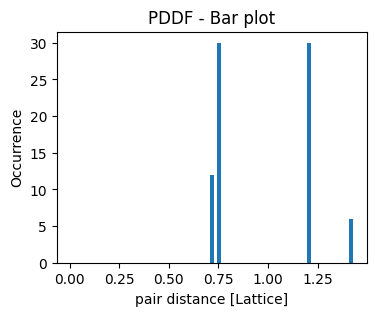

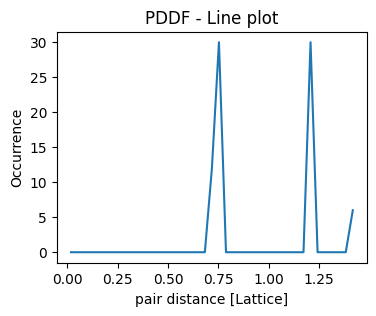

In [7]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [Lattice]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [Lattice]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

In [8]:
# Check that the sum of the occurrances of the PDDF corresponds to the number of pairs expected.

print(sum(pddf[1]))
print((561*560)/2)

78
157080.0


### PDDF in \AA

In [9]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice

pddf = pddf_calculator(coords, bin_width = my_bin_size_aa, use_lattice_units=False)
print(pddf)

(array([0.0713825, 0.2141475, 0.3569125, 0.4996775, 0.6424425, 0.7852075,
       0.9279725, 1.0707375, 1.2135025, 1.3562675, 1.4990325, 1.6417975,
       1.7845625, 1.9273275, 2.0700925, 2.2128575, 2.3556225, 2.4983875,
       2.6411525, 2.7839175, 2.9266825, 3.0694475, 3.2122125, 3.3549775,
       3.4977425, 3.6405075, 3.7832725, 3.9260375, 4.0688025, 4.2115675,
       4.3543325, 4.4970975, 4.6398625, 4.7826275, 4.9253925, 5.0681575,
       5.2109225, 5.3536875, 5.4964525, 5.6392175, 5.7819825]), array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, 12, 30,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       30,  0,  0,  0,  0,  0,  6]))


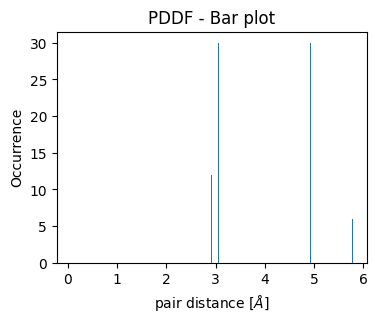

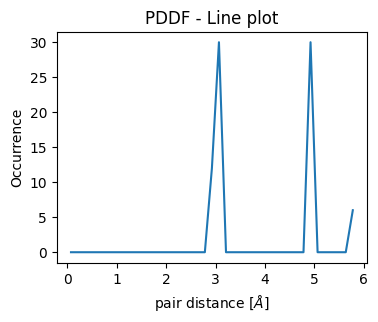

In [10]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

### RDF

In [11]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice

#com_rdf = com_rdf_calculator(coords, elements=el, bin_width = my_bin_size_aa)
com_rdf = com_rdf_calculator(coords, bin_width = my_bin_size_aa, elements=el)


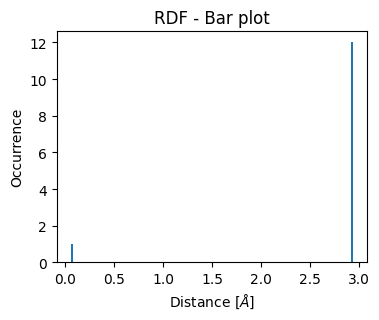

In [12]:
plt.figure(figsize=(xfig, yfig))
plt.bar(com_rdf[0], com_rdf[1], width=0.02)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()

### Let's begin - Multiple frame xyz file

In [13]:
# Here you have to define: (1) the path where your stucture is. (2) the name of the file you want to analyse. (3) the lattice of the chemical specie.
path_file="tutorial_structures"
file="sintering.xyz"
my_lattice=4.079

In [14]:
# Here the code read the xyz file
el, coords= read_xyz_movie(absolute_path + '/' + path_file + '/' + file)

# check the number of frame and save on a variable
nframe=len(coords)
print(nframe)

401


In [15]:
my_bin_size_lattice = 0.035

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator(coords[t], bin_width = my_bin_size_lattice, use_lattice_units=True, lattice=my_lattice)

    # print the pddf only for one frame for a quick check
    if t==0:
        print(pddf)

    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

(array([0.0175, 0.0525, 0.0875, 0.1225, 0.1575, 0.1925, 0.2275, 0.2625,
       0.2975, 0.3325, 0.3675, 0.4025, 0.4375, 0.4725, 0.5075, 0.5425,
       0.5775, 0.6125, 0.6475, 0.6825, 0.7175, 0.7525, 0.7875, 0.8225,
       0.8575, 0.8925, 0.9275, 0.9625, 0.9975, 1.0325, 1.0675, 1.1025,
       1.1375, 1.1725, 1.2075, 1.2425, 1.2775, 1.3125, 1.3475, 1.3825,
       1.4175, 1.4525, 1.4875, 1.5225, 1.5575, 1.5925, 1.6275, 1.6625,
       1.6975, 1.7325, 1.7675, 1.8025, 1.8375, 1.8725, 1.9075, 1.9425,
       1.9775, 2.0125, 2.0475, 2.0825, 2.1175, 2.1525, 2.1875, 2.2225,
       2.2575, 2.2925, 2.3275, 2.3625, 2.3975, 2.4325, 2.4675, 2.5025,
       2.5375, 2.5725, 2.6075, 2.6425, 2.6775, 2.7125, 2.7475, 2.7825,
       2.8175, 2.8525, 2.8875, 2.9225, 2.9575, 2.9925, 3.0275, 3.0625,
       3.0975, 3.1325, 3.1675, 3.2025, 3.2375, 3.2725, 3.3075, 3.3425,
       3.3775, 3.4125, 3.4475, 3.4825, 3.5175, 3.5525, 3.5875, 3.6225,
       3.6575, 3.6925, 3.7275, 3.7625, 3.7975, 3.8325, 3.8675, 3.9025,
     

#### Plot one frame

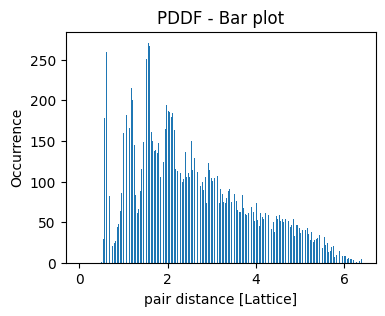

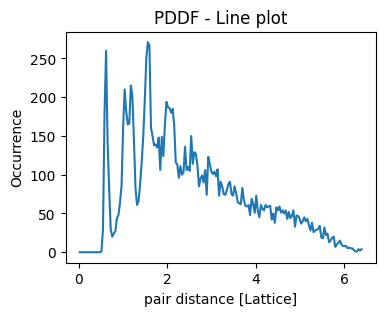

In [16]:
t=1 #choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [Lattice]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [Lattice]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

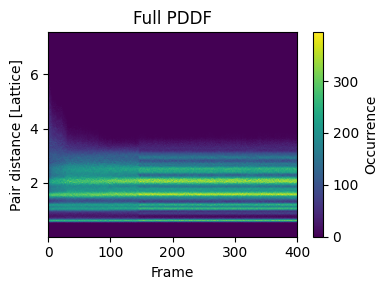

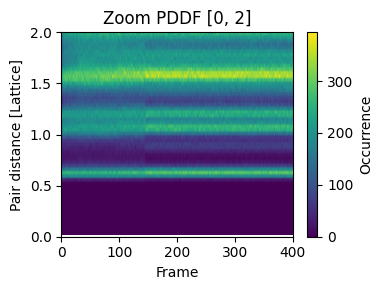

In [17]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)

r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_lattice,
    my_bin_size_lattice
)

nbins_common = len(r_common)


# Heatmap matrix
H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    n = len(occ_list[t])
    H[t, :n] = occ_list[t]



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [Lattice]")
plt.colorbar(im, label="Occurrence")
plt.title("Full PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 2

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [Lattice]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### PDDF in \AA

In [18]:
my_bin_size_lattice = 0.035
my_bin_size_aa= my_bin_size_lattice*my_lattice

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator(coords[t], bin_width = my_bin_size_aa, use_lattice_units=False)

    # print the pddf only for one frame for a quick check
    if t==0:
        print(pddf)

    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

(array([ 0.0713825,  0.2141475,  0.3569125,  0.4996775,  0.6424425,
        0.7852075,  0.9279725,  1.0707375,  1.2135025,  1.3562675,
        1.4990325,  1.6417975,  1.7845625,  1.9273275,  2.0700925,
        2.2128575,  2.3556225,  2.4983875,  2.6411525,  2.7839175,
        2.9266825,  3.0694475,  3.2122125,  3.3549775,  3.4977425,
        3.6405075,  3.7832725,  3.9260375,  4.0688025,  4.2115675,
        4.3543325,  4.4970975,  4.6398625,  4.7826275,  4.9253925,
        5.0681575,  5.2109225,  5.3536875,  5.4964525,  5.6392175,
        5.7819825,  5.9247475,  6.0675125,  6.2102775,  6.3530425,
        6.4958075,  6.6385725,  6.7813375,  6.9241025,  7.0668675,
        7.2096325,  7.3523975,  7.4951625,  7.6379275,  7.7806925,
        7.9234575,  8.0662225,  8.2089875,  8.3517525,  8.4945175,
        8.6372825,  8.7800475,  8.9228125,  9.0655775,  9.2083425,
        9.3511075,  9.4938725,  9.6366375,  9.7794025,  9.9221675,
       10.0649325, 10.2076975, 10.3504625, 10.4932275, 10.635

#### Plot one frame

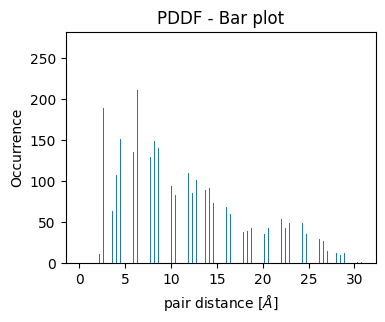

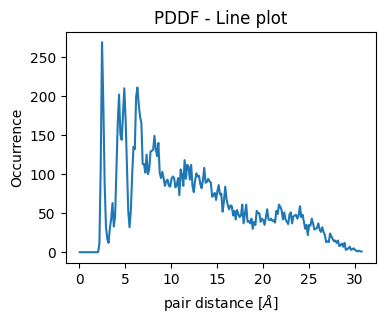

In [19]:
t=0 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

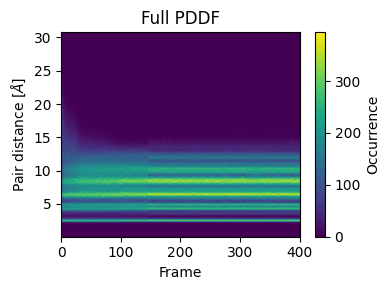

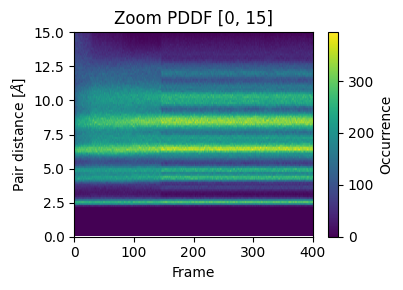

In [20]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("Full PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### RDF

In [21]:
my_bin_size_lattice = 0.035
my_bin_size_aa= my_bin_size_lattice*my_lattice

bins_list = []
occ_list = []

for t in range(nframe):
    com_rdf = com_rdf_calculator(coords[t],  elements=el[t], bin_width = my_bin_size_aa)

    # print the pddf only for one frame for a quick check
    if t==0:
        print(com_rdf)

    bins_list.append(com_rdf[0])
    occ_list.append(com_rdf[1])

(array([ 0.0713825,  0.2141475,  0.3569125,  0.4996775,  0.6424425,
        0.7852075,  0.9279725,  1.0707375,  1.2135025,  1.3562675,
        1.4990325,  1.6417975,  1.7845625,  1.9273275,  2.0700925,
        2.2128575,  2.3556225,  2.4983875,  2.6411525,  2.7839175,
        2.9266825,  3.0694475,  3.2122125,  3.3549775,  3.4977425,
        3.6405075,  3.7832725,  3.9260375,  4.0688025,  4.2115675,
        4.3543325,  4.4970975,  4.6398625,  4.7826275,  4.9253925,
        5.0681575,  5.2109225,  5.3536875,  5.4964525,  5.6392175,
        5.7819825,  5.9247475,  6.0675125,  6.2102775,  6.3530425,
        6.4958075,  6.6385725,  6.7813375,  6.9241025,  7.0668675,
        7.2096325,  7.3523975,  7.4951625,  7.6379275,  7.7806925,
        7.9234575,  8.0662225,  8.2089875,  8.3517525,  8.4945175,
        8.6372825,  8.7800475,  8.9228125,  9.0655775,  9.2083425,
        9.3511075,  9.4938725,  9.6366375,  9.7794025,  9.9221675,
       10.0649325, 10.2076975, 10.3504625, 10.4932275, 10.635

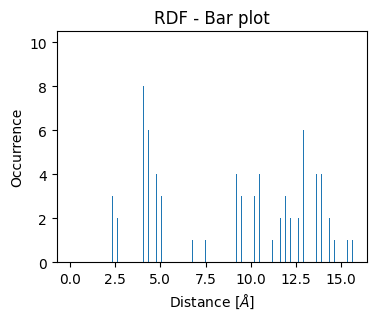

In [22]:
plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[0], occ_list[0], width=0.02)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()

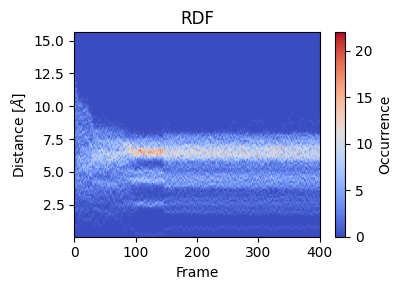

In [23]:
# Create a common grid for different possible lenght of RDF at different frames
nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)


plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='coolwarm'
)
plt.xlabel("Frame")
plt.ylabel("Distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("RDF")
plt.tight_layout()
plt.show()
